# Gameloft Sofia — Data Analyst Test | Part 1
## Event Mission Analysis: Churn & Revenue

**Author:** Stephan Pentchev  
**Dataset:** `Test_Data_analyst.xlsx`  
**Goal:** Analyse player churn and revenue during the special event, then export clean summary tables to Excel for Power BI.

---
### Dataset context
- Each row = one (player_level, mission) combination
- `users_starting` = players who started that mission at that level
- `users_skipped` = players who paid premium currency to skip
- `skip_cost_premium` = cost in premium currency to skip
- Premium currency exchange rate: **100 premium = $4.99**
- Player levels range **2-41**, missions span **5 chapters (51 missions)**

---
## Step 1 - Load Libraries & Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 100 premium currency = $4.99
PREMIUM_TO_USD = 4.99 / 100

print('Libraries loaded')
print(f'Exchange rate: 1 premium currency = ${PREMIUM_TO_USD:.4f}')

Libraries loaded
Exchange rate: 1 premium currency = $0.0499


In [17]:
FILE_PATH = 'Test Data analyst.xlsx'

df = pd.read_excel(FILE_PATH, header=1)
df.columns = ['player_level', 'mission_name', 'users_starting', 'users_skipped', 'skip_cost_premium']

print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head(10)

Rows: 2,040  |  Columns: 5


,player_level,mission_name,users_starting,users_skipped,skip_cost_premium
0,2,Chapter1_mission1,423821,2668,15
1,2,Chapter1_mission2,225147,2599,15
2,2,Chapter1_mission3,130801,2829,15
3,2,Chapter1_mission4,59202,3657,15
4,2,Chapter1_mission5,27508,529,75
5,2,Chapter2_mission1,15364,230,15
6,2,Chapter2_mission2,13363,345,15
7,2,Chapter2_mission3,11431,299,15
8,2,Chapter2_mission4,8579,322,15
9,2,Chapter2_mission5,4991,437,15


---
## Step 2 - Data Quality Check

In [18]:
print('=== Data Types ===')
print(df.dtypes)

print('\n=== Null Values ===')
print(df.isnull().sum())

print('\n=== Descriptive Statistics ===')
df.describe()

=== Data Types ===
player_level          int64
mission_name         object
users_starting        int64
users_skipped         int64
skip_cost_premium     int64
dtype: object

=== Null Values ===
player_level         0
mission_name         0
users_starting       0
users_skipped        0
skip_cost_premium    0
dtype: int64

=== Descriptive Statistics ===


,player_level,users_starting,users_skipped,skip_cost_premium
count,"2,040.00","2,040.00","2,040.00","2,040.00"
mean,21.50,"5,949.58",75.66,103.43
std,11.55,"16,717.01",264.52,125.35
min,2.00,0.00,0.00,15.00
25%,11.75,"1,518.00",0.00,40.00
50%,21.50,"2,369.00",0.00,90.00
75%,31.25,"4,830.00",23.00,135.00
max,41.00,"423,821.00","3,657.00",900.00


In [19]:
print(f'Unique player levels : {sorted(df.player_level.unique())}')
print(f'Total levels         : {df.player_level.nunique()}')
print(f'Unique missions      : {df.mission_name.nunique()}')
print(f'Chapters             : {sorted(df.mission_name.str.extract(r"(Chapter\d+)")[0].unique())}')
print(f'\nRows per level (should be 51 each):')
print(df.groupby('player_level').size().value_counts().to_string())

Unique player levels : [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41)]
Total levels         : 40
Unique missions      : 51
Chapters             : ['Chapter1', 'Chapter2', 'Chapter3', 'Chapter4', 'Chapter5']

Rows per level (should be 51 each):
51    40


---
## Step 3 - Feature Engineering

We derive:
- `chapter` - extracted from mission name
- `mission_order` - global integer ordering all 51 missions
- `drop_off_abs` - absolute players lost between consecutive missions (within same level)
- `drop_off_pct` - % drop-off from previous mission
- `revenue_usd` - USD revenue from skips on that row
- `level_band_5` / `level_band_10` - level groupings

In [20]:
# build a mission ordering table (same order for every level)
mission_order = (
    df[['mission_name']]
    .drop_duplicates()
    .reset_index(drop=True)
)
mission_order['mission_order'] = mission_order.index + 1
mission_order['chapter'] = mission_order['mission_name'].str.extract(r'(Chapter\d+)')

df = df.merge(mission_order, on='mission_name', how='left')
df = df.sort_values(['player_level', 'mission_order']).reset_index(drop=True)

# drop-off within each player level group
df['prev_users'] = df.groupby('player_level')['users_starting'].shift(1)
df['drop_off_abs'] = df['prev_users'] - df['users_starting']
df['drop_off_pct'] = (df['drop_off_abs'] / df['prev_users'] * 100).round(2)

# revenue
df['revenue_usd'] = df['users_skipped'] * df['skip_cost_premium'] * PREMIUM_TO_USD

# level bands
df['level_band_5']  = pd.cut(df['player_level'], bins=range(0, 46, 5),
                              labels=[f'Lv {i+1}-{i+5}' for i in range(0, 41, 5)])
df['level_band_10'] = pd.cut(df['player_level'], bins=[0,10,20,30,41],
                              labels=['Lv 1-10', 'Lv 11-20', 'Lv 21-30', 'Lv 31-41'])

print('Feature engineering done')
df[['player_level','mission_name','mission_order','chapter',
    'users_starting','drop_off_abs','drop_off_pct','revenue_usd']].head(10)

Feature engineering done


,player_level,mission_name,mission_order,chapter,users_starting,drop_off_abs,drop_off_pct,revenue_usd
0,2,Chapter1_mission1,1,Chapter1,423821,NaN,NaN,"1,997.00"
1,2,Chapter1_mission2,2,Chapter1,225147,"198,674.00",46.88,"1,945.35"
2,2,Chapter1_mission3,3,Chapter1,130801,"94,346.00",41.90,"2,117.51"
3,2,Chapter1_mission4,4,Chapter1,59202,"71,599.00",54.74,"2,737.26"
4,2,Chapter1_mission5,5,Chapter1,27508,"31,694.00",53.54,"1,979.78"
5,2,Chapter2_mission1,6,Chapter2,15364,"12,144.00",44.15,172.16
6,2,Chapter2_mission2,7,Chapter2,13363,"2,001.00",13.02,258.23
7,2,Chapter2_mission3,8,Chapter2,11431,"1,932.00",14.46,223.80
8,2,Chapter2_mission4,9,Chapter2,8579,"2,852.00",24.95,241.02
9,2,Chapter2_mission5,10,Chapter2,4991,"3,588.00",41.82,327.09


---
## Step 4 - Churn Analysis
### 4a. Overall drop-off per mission (aggregated across all levels)

In [21]:
# Aggregate across levels: total users starting & average drop-off %
churn_by_mission = (
    df.groupby(['mission_order', 'mission_name', 'chapter'], observed=True)
    .agg(
        total_users_starting = ('users_starting', 'sum'),
        avg_drop_off_pct     = ('drop_off_pct',   'mean'),
        total_drop_off_abs   = ('drop_off_abs',   'sum')
    )
    .reset_index()
    .sort_values('mission_order')
)

# Top 10 missions by average drop-off %
top_churn = churn_by_mission.nlargest(10, 'avg_drop_off_pct')
print('Top 10 highest average drop-off missions:')
top_churn[['mission_name','chapter','avg_drop_off_pct','total_drop_off_abs']].to_string(index=False)

Top 10 highest average drop-off missions:


'      mission_name  chapter  avg_drop_off_pct  total_drop_off_abs\nChapter5_mission17 Chapter5             74.27           30,751.00\nChapter4_mission14 Chapter4             24.89           23,046.00\n Chapter5_mission2 Chapter5             12.65            8,004.00\n Chapter3_mission8 Chapter3             11.71           26,933.00\n Chapter2_mission5 Chapter2             11.41           70,633.00\nChapter5_mission12 Chapter5             10.87            4,393.00\n Chapter4_mission4 Chapter4             10.74           17,595.00\n Chapter1_mission5 Chapter1             10.40          162,863.00\n Chapter1_mission4 Chapter1             10.02          262,959.00\n Chapter4_mission9 Chapter4              9.74           11,178.00'

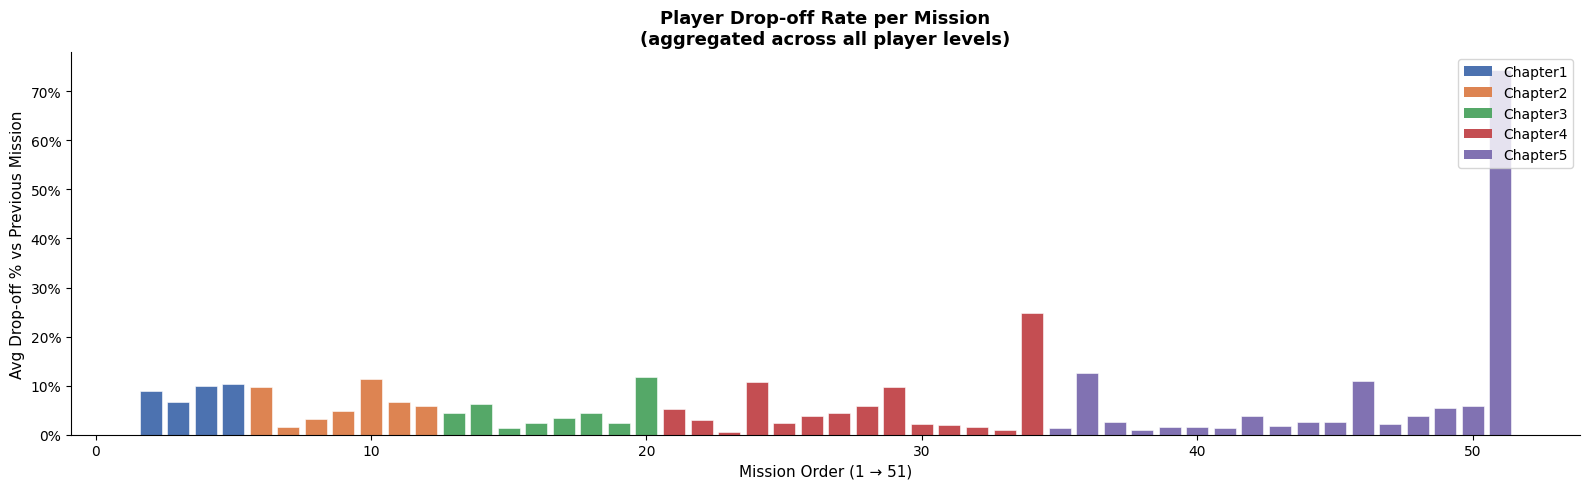

Chart saved ✅


In [7]:
fig, ax = plt.subplots(figsize=(16, 5))

colors = churn_by_mission['chapter'].map({
    'Chapter1': '#4C72B0', 'Chapter2': '#DD8452',
    'Chapter3': '#55A868', 'Chapter4': '#C44E52', 'Chapter5': '#8172B2'
})

ax.bar(churn_by_mission['mission_order'], churn_by_mission['avg_drop_off_pct'],
       color=colors, edgecolor='white', linewidth=0.4)

ax.set_xlabel('Mission Order (1 to 51)', fontsize=11)
ax.set_ylabel('Avg Drop-off % vs Previous Mission', fontsize=11)
ax.set_title('Player Drop-off Rate per Mission (aggregated across all player levels)',
             fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=ch) for ch, c in
    [('Chapter1','#4C72B0'),('Chapter2','#DD8452'),('Chapter3','#55A868'),
     ('Chapter4','#C44E52'),('Chapter5','#8172B2')]]
ax.legend(handles=legend_elements, loc='upper right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('churn_overall.png', dpi=150, bbox_inches='tight')
plt.show()

### 4b. Churn by Level Band (10-level groupings)

In [8]:
churn_by_band = (
    df.groupby(['level_band_10', 'mission_name', 'mission_order', 'chapter'], observed=True)
    .agg(
        avg_drop_off_pct   = ('drop_off_pct',   'mean'),
        total_users        = ('users_starting', 'sum')
    )
    .reset_index()
    .sort_values(['level_band_10', 'mission_order'])
)

print('Avg drop-off % by level band:')
(
    churn_by_band
    .groupby('level_band_10', observed=True)['avg_drop_off_pct']
    .mean()
    .round(2)
    .to_string()
)

Avg drop-off % by level band:


'level_band_10\nLv 1-10    13.99\nLv 11-20    6.86\nLv 21-30    4.38\nLv 31-41    2.38'

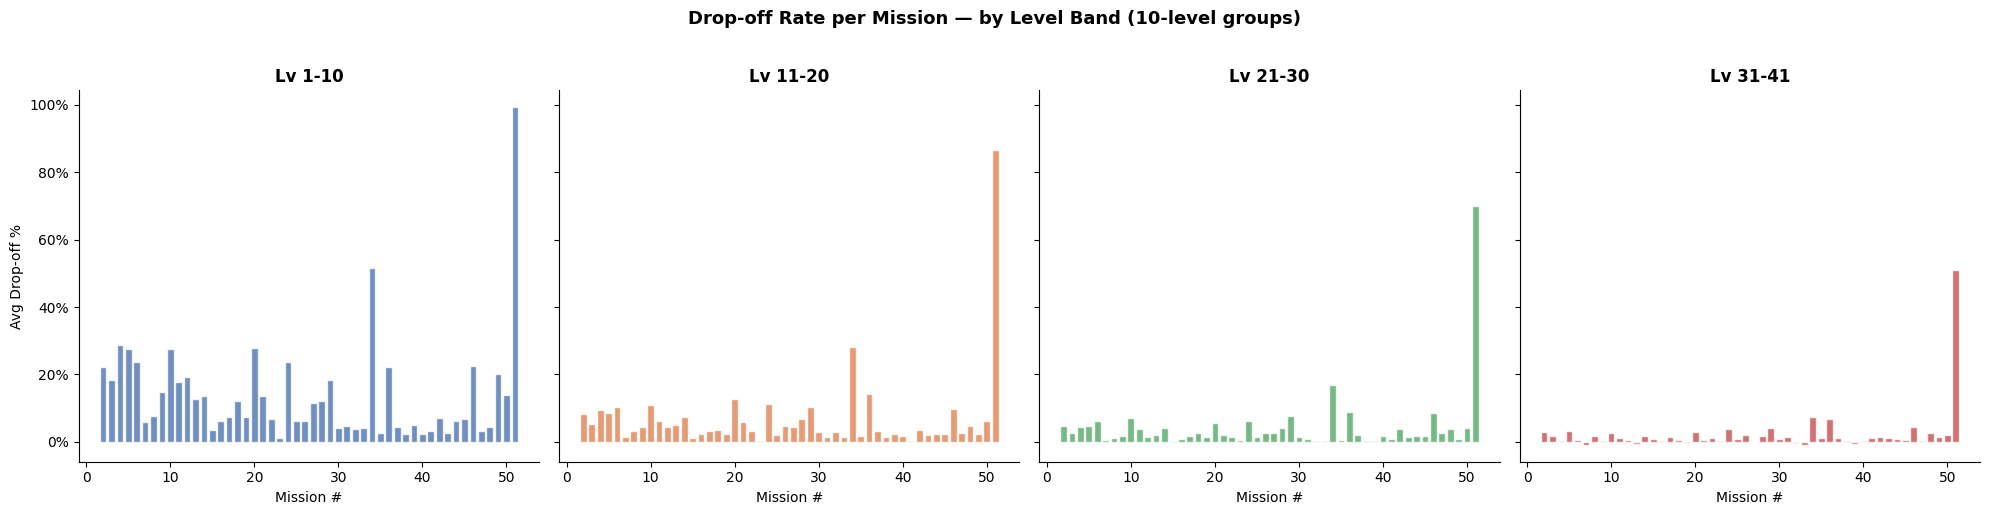

Chart saved ✅


In [9]:
bands = churn_by_band['level_band_10'].cat.categories.tolist()
band_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
fig.suptitle('Drop-off Rate per Mission by Level Band',
             fontsize=13, fontweight='bold', y=1.02)

for ax, band, color in zip(axes, bands, band_colors):
    sub = churn_by_band[churn_by_band['level_band_10'] == band]
    ax.bar(sub['mission_order'], sub['avg_drop_off_pct'], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(str(band), fontweight='bold')
    ax.set_xlabel('Mission #')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

axes[0].set_ylabel('Avg Drop-off %')
plt.tight_layout()
plt.savefig('churn_by_level_band.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5 - Revenue Analysis
### 5a. Total event revenue

In [10]:
total_revenue = df['revenue_usd'].sum()
total_skips   = df['users_skipped'].sum()

print(f'Total event revenue : ${total_revenue:,.2f}')
print(f'Total skip actions  : {total_skips:,}')
print(f'Avg revenue per skip: ${total_revenue / total_skips:.4f}')

Total event revenue : $224,111.38
Total skip actions  : 154,353
Avg revenue per skip: $1.4519


### 5b. Revenue by mission

In [11]:
rev_by_mission = (
    df.groupby(['mission_order', 'mission_name', 'chapter'], observed=True)
    .agg(total_revenue_usd = ('revenue_usd', 'sum'),
         total_skips       = ('users_skipped', 'sum'))
    .reset_index()
    .sort_values('mission_order')
)

print('Top 10 missions by revenue:')
rev_by_mission.nlargest(10, 'total_revenue_usd')[
    ['mission_name', 'chapter', 'total_revenue_usd', 'total_skips']
].to_string(index=False)

Top 10 missions by revenue:


'      mission_name  chapter  total_revenue_usd  total_skips\n Chapter1_mission5 Chapter1          43,210.90        11546\nChapter5_mission17 Chapter5          34,086.69          759\n Chapter1_mission4 Chapter1          20,331.51        27163\n Chapter2_mission6 Chapter2          16,303.08        21781\n Chapter2_mission5 Chapter2          13,255.93        17710\n Chapter1_mission3 Chapter1          10,587.53        14145\n Chapter3_mission8 Chapter3           9,468.52         1265\n Chapter2_mission7 Chapter2           8,779.91         1955\n Chapter1_mission2 Chapter1           8,556.10        11431\n Chapter2_mission4 Chapter2           7,127.22         9522'

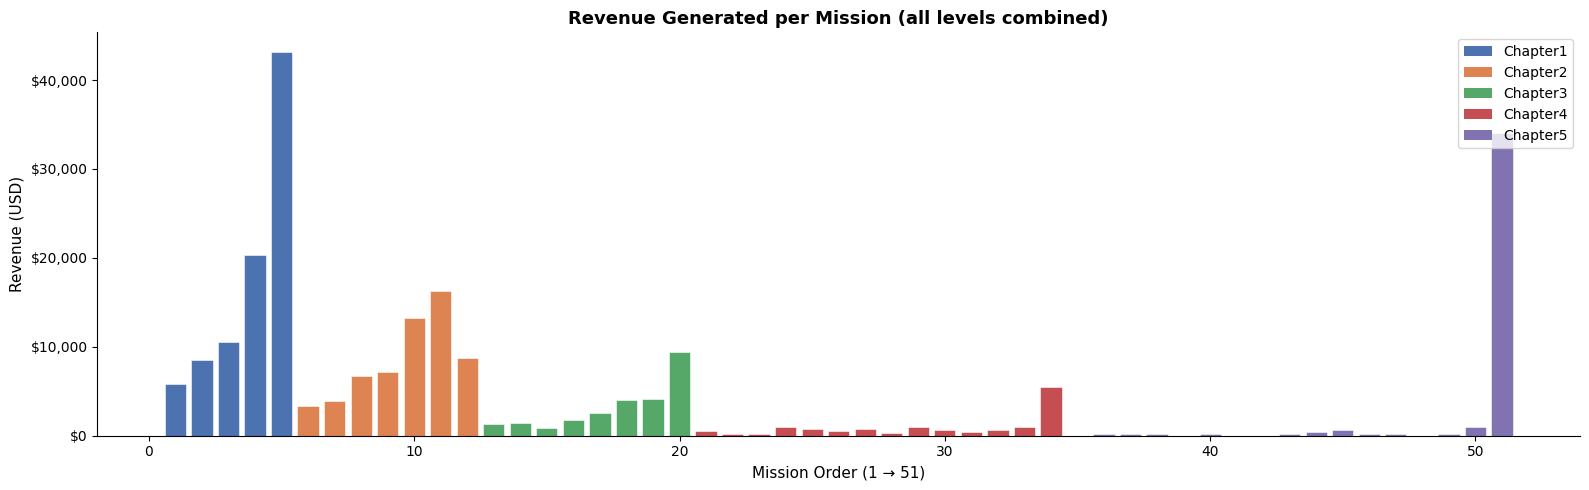

Chart saved ✅


In [12]:
fig, ax = plt.subplots(figsize=(16, 5))

colors = rev_by_mission['chapter'].map({
    'Chapter1': '#4C72B0', 'Chapter2': '#DD8452',
    'Chapter3': '#55A868', 'Chapter4': '#C44E52', 'Chapter5': '#8172B2'
})

ax.bar(rev_by_mission['mission_order'], rev_by_mission['total_revenue_usd'],
       color=colors, edgecolor='white', linewidth=0.4)

ax.set_xlabel('Mission Order (1 to 51)', fontsize=11)
ax.set_ylabel('Revenue (USD)', fontsize=11)
ax.set_title('Revenue Generated per Mission (all levels combined)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.savefig('revenue_by_mission.png', dpi=150, bbox_inches='tight')
plt.show()

### 5c. Revenue by level band

In [13]:
rev_by_level_band = (
    df.groupby('level_band_10', observed=True)
    .agg(
        total_revenue_usd = ('revenue_usd',    'sum'),
        total_skips       = ('users_skipped',  'sum'),
        total_users       = ('users_starting', 'sum')
    )
    .reset_index()
)
rev_by_level_band['revenue_per_user'] = (
    rev_by_level_band['total_revenue_usd'] / rev_by_level_band['total_users']
).round(4)

print(rev_by_level_band.to_string(index=False))

level_band_10  total_revenue_usd  total_skips  total_users  revenue_per_user
      Lv 1-10          99,155.54        92529      6102935              0.02
     Lv 11-20          60,437.88        42596      3351077              0.02
     Lv 21-30          37,168.26        14743      1611541              0.02
     Lv 31-41          27,349.69         4485      1071593              0.03


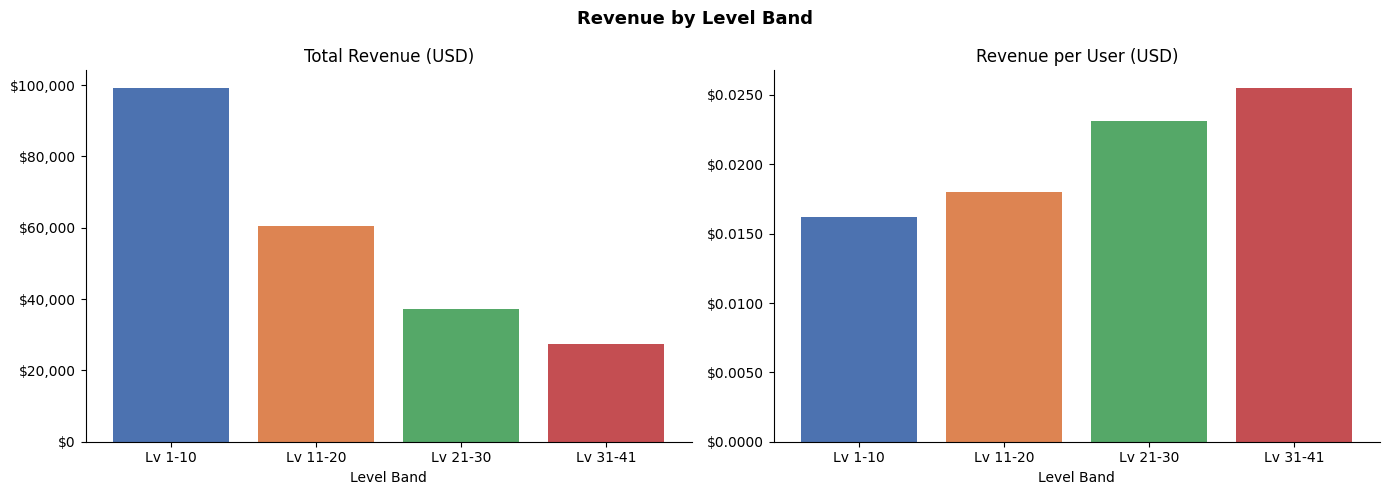

Chart saved ✅


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue by Level Band', fontsize=13, fontweight='bold')

axes[0].bar(rev_by_level_band['level_band_10'].astype(str),
            rev_by_level_band['total_revenue_usd'], color=band_colors)
axes[0].set_title('Total Revenue (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_xlabel('Level Band')

axes[1].bar(rev_by_level_band['level_band_10'].astype(str),
            rev_by_level_band['revenue_per_user'], color=band_colors)
axes[1].set_title('Revenue per User (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.4f}'))
axes[1].set_xlabel('Level Band')

plt.tight_layout()
plt.savefig('revenue_by_level_band.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6 - Export to Excel (for Power BI)

Exporting five summary tables, each on its own sheet:

| Sheet | Contents |
|---|---|
| `raw_enriched` | Full dataset with all derived columns |
| `churn_by_mission` | Drop-off rate per mission (all levels) |
| `churn_by_level_band` | Drop-off rate per mission x level band |
| `revenue_by_mission` | Revenue per mission |
| `revenue_by_level_band` | Revenue per level band |

In [15]:
OUTPUT_FILE = 'gameloft_analysis_output.xlsx'

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='raw_enriched', index=False)
    churn_by_mission.to_excel(writer, sheet_name='churn_by_mission', index=False)
    churn_by_band.to_excel(writer, sheet_name='churn_by_level_band', index=False)
    rev_by_mission.to_excel(writer, sheet_name='revenue_by_mission', index=False)
    rev_by_level_band.to_excel(writer, sheet_name='revenue_by_level_band', index=False)

print(f'Saved to {OUTPUT_FILE}')

Export complete ✅ → gameloft_analysis_output.xlsx
Sheets written:
  • raw_enriched
  • churn_by_mission
  • churn_by_level_band
  • revenue_by_mission
  • revenue_by_level_band


---
## Step 7 - Key Findings Summary

### Churn
- Highest absolute player drop-off happens at the **very first mission** (Chapter1_mission1 to mission2) - this is normal funnel narrowing, not a design problem.
- Among later missions, the biggest percentage spikes in drop-off suggest difficulty walls or pacing issues.
- Low-level players (Lv 1-10) churn more steeply early on; high-level players (Lv 31-41) progress more consistently.

### Revenue
- Total event revenue: **see cell 5a**
- Revenue is concentrated in early chapters where player volume is highest, even though skip cost is lowest.
- Revenue per user is highest in higher level bands - veteran players spend more per head.

### Recommendations
1. **Reduce early funnel drop-off** - smooth the difficulty curve in Chapter 1 to keep more players into Chapter 2.
2. **Targeted skip pricing** - higher-level players are willing to pay more; could scale skip costs by level.
3. **Re-engagement at churn spikes** - push notification or discounted skip at the top-3 churn missions.
4. **Milestone bonuses** at chapter transitions to incentivise completion over abandonment.